<a href="https://colab.research.google.com/github/sydneythompson11/Advanced-ML/blob/main/Inclass_05_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 RNN

### Importing libraries

In [ ]:
# Libraries

import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Load & inspect data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load and inspect Bitcoin data

bitcoin = pd.read_csv("dc.csv")

bitcoin = bitcoin.rename(
    columns={"Unnamed: 0": "date"}
)

bitcoin["date"] = pd.to_datetime(bitcoin["date"])

bitcoin = (
    bitcoin
    .sort_values("date")
    .reset_index(drop=True)
)

print(bitcoin.shape)

bitcoin.head()

(1000, 6)


,date,open_USD,high_USD,low_USD,close_USD,volume
0,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
1,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
2,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
3,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
4,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227


In [ ]:
# Basic inspection

bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[ns]
 1   open_USD   1000 non-null   float64       
 2   high_USD   1000 non-null   float64       
 3   low_USD    1000 non-null   float64       
 4   close_USD  1000 non-null   float64       
 5   volume     1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.0 KB


In [ ]:
# Summary statistics

bitcoin.describe()

,date,open_USD,high_USD,low_USD,close_USD,volume
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019-09-18 12:00:00,9285.762120,9542.880270,9011.393200,9310.335850,53100.498000
min,2018-05-07 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,5743.000000
25%,2019-01-11 18:00:00,6467.192500,6582.255000,6325.015000,6466.762500,30045.750000
50%,2019-09-18 12:00:00,8189.695000,8351.630000,8002.045000,8189.330000,43795.500000
75%,2020-05-25 06:00:00,10216.860000,10419.562500,9907.977500,10220.170000,64909.250000
max,2021-01-30 00:00:00,40586.960000,41950.000000,38720.000000,40582.810000,402201.000000
std,NaN,5793.522832,6075.604427,5483.524463,5846.917681,35329.832031


Visualizing the target variable

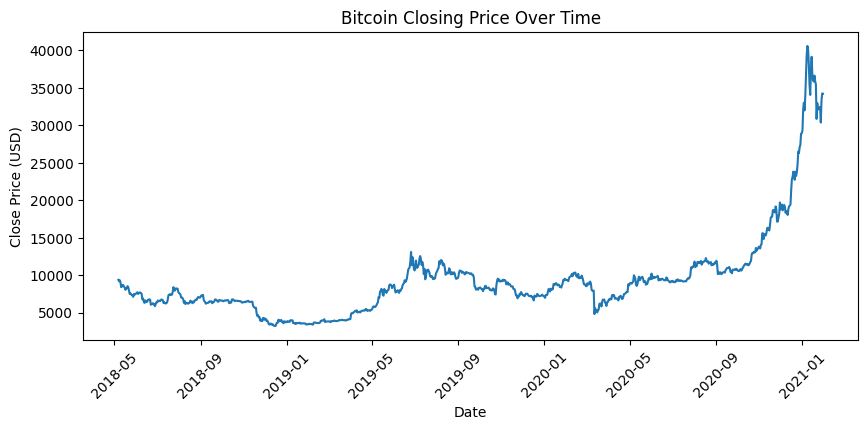

In [ ]:
# Visualize closing price over time

plt.figure(figsize=(10, 4))

plt.plot(
    bitcoin["date"],
    bitcoin["close_USD"]
)

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.show()

### Preparing data for recurrent modeling

In [ ]:
# Prepare Bitcoin data for recurrent models

features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]

target_col = "close_USD"

bitcoin_model = bitcoin[["date"] + features].copy()

print("Unique dates:", bitcoin_model["date"].nunique())
print("Rows:", len(bitcoin_model))

scaler_bitcoin = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_bitcoin.fit_transform(
    bitcoin_model[features]
)

look_back = 10                                                  # use 10 previous days to predict next close

target_index = features.index(target_col)

Unique dates: 1000
Rows: 1000


### Useful functions

In [ ]:
# Function to create recurrent sequence windows

def create_sequences(dataset, target_index, look_back=10):

    X, y = [], []

    for i in range(len(dataset) - look_back):

        X.append(
            dataset[i:i + look_back, :]
        )                                                       # previous look_back days

        y.append(
            dataset[i + look_back, target_index]
        )                                                       # next day's close_USD

    return np.array(X), np.array(y)

In [ ]:
# Function to visualize training curves

def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(
        history.history["loss"],
        label="Training Loss"
    )

    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    axes[0].legend()

    # MAE
    axes[1].plot(
        history.history["mean_absolute_error"],
        label="Training MAE"
    )

    axes[1].plot(
        history.history["val_mean_absolute_error"],
        label="Validation MAE"
    )

    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")

    axes[1].legend()

    plt.tight_layout()

    plt.show()

In [ ]:
# Function to evaluate forecasting performance

def evaluate_and_plot(
    model,
    trainX,
    testX,
    trainY,
    testY,
    scaler,
    target_index,
    title
):

    # Predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Create arrays for inverse scaling
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))

    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()

    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))

    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY

    # Inverse transform
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]

    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))

    plt.plot(
        testY_inv,
        label="Actual"
    )

    plt.plot(
        test_pred_inv,
        label="Predicted"
    )

    plt.title(title + " Test Predictions")

    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(
        style="plain",
        axis="y"
    )

    plt.legend()

    plt.show()

In [ ]:
# Function to compare model metrics

def evaluate_metrics(
    model,
    testX,
    testY,
    scaler,
    target_index
):

    test_pred = model.predict(testX)

    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()

    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY

    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Creating train/test recurrent tensors

In [ ]:
# Create train/test recurrent tensors

train_size = int(len(scaled_features) * 0.8)                    # chronological 80/20 split

train_bitcoin = scaled_features[:train_size]                    # earlier data
test_bitcoin = scaled_features[train_size:]                     # held-out future data

trainX_bitcoin, trainY_bitcoin = create_sequences(
    train_bitcoin,
    target_index,
    look_back
)

testX_bitcoin, testY_bitcoin = create_sequences(
    test_bitcoin,
    target_index,
    look_back
)

print("trainX_bitcoin shape:", trainX_bitcoin.shape)
print("testX_bitcoin shape:", testX_bitcoin.shape)
print("trainY_bitcoin shape:", trainY_bitcoin.shape)
print("testY_bitcoin shape:", testY_bitcoin.shape)

trainX_bitcoin shape: (790, 10, 5)
testX_bitcoin shape: (190, 10, 5)
trainY_bitcoin shape: (790,)
testY_bitcoin shape: (190,)


### Baseline SimpleRNN model

In [ ]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        8,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0108 - mean_absolute_error: 0.0820 - val_loss: 0.0113 - val_mean_absolute_error: 0.0747
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041 - mean_absolute_error: 0.0477 - val_loss: 0.0080 - val_mean_absolute_error: 0.0571
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - mean_absolute_error: 0.0402 - val_loss: 0.0062 - val_mean_absolute_error: 0.0496
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022 - mean_absolute_error: 0.0343 - val_loss: 0.0049 - val_mean_absolute_error: 0.0438
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - mean_absolute_error: 0.0304 - val_loss: 0.0039 - val_mean_absolute_error: 0.0391
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - mean_absolute_error: 0.0279 - val_loss: 0.0032 - val_mean_absolute_error: 0.0353
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - mean_absolute_error: 0.0259 - val_loss: 0.0026 - 

Visualizing training

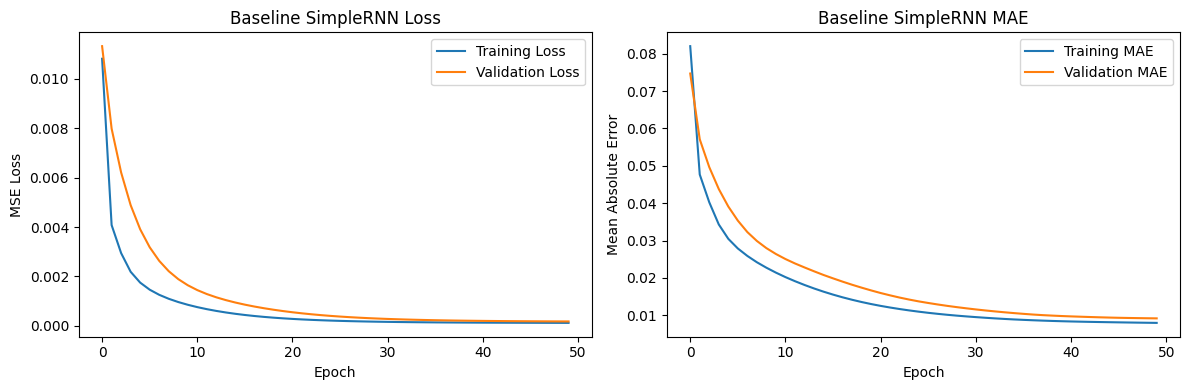

In [ ]:
# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Baseline SimpleRNN Train RMSE: 493.52
Baseline SimpleRNN Test RMSE: 3953.11
Baseline SimpleRNN Train MAE: 364.83
Baseline SimpleRNN Test MAE: 2409.82


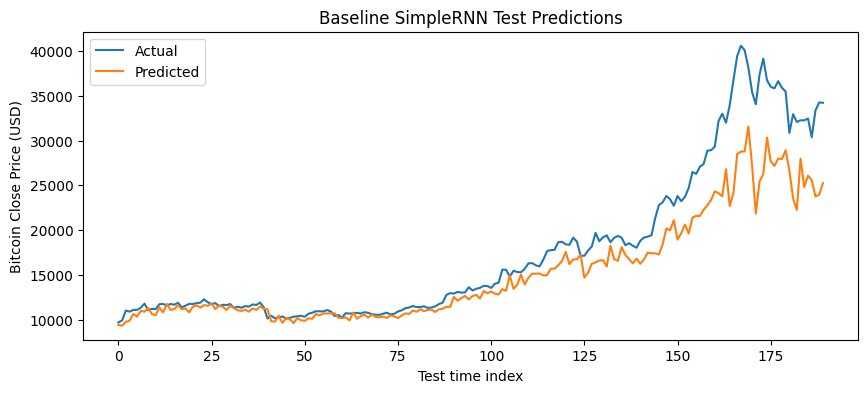

In [ ]:
# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

### Baseline LSTM Model

In [ ]:
# Build and train baseline LSTM model

lstm_model = Sequential([
    LSTM(
        8,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0018 - mean_absolute_error: 0.0332 - val_loss: 0.0052 - val_mean_absolute_error: 0.0536
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mean_absolute_error: 0.0257 - val_loss: 0.0043 - val_mean_absolute_error: 0.0484
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7141e-04 - mean_absolute_error: 0.0183 - val_loss: 0.0033 - val_mean_absolute_error: 0.0409
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.8698e-04 - mean_absolute_error: 0.0150 - val_loss: 0.0024 - val_mean_absolute_error: 0.0340
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.2297e-04 - mean_absolute_error: 0.0139 - val_loss: 0.0019 - val_mean_absolute_error: 0.0293
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8944e-04 - mean_absolute_error: 0.0132 - val_loss: 0.0015 - val_mean_absolute_error: 0.0259
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.6544e-04 - mean_absolute_error: 0.0126 - val

Visualizing training

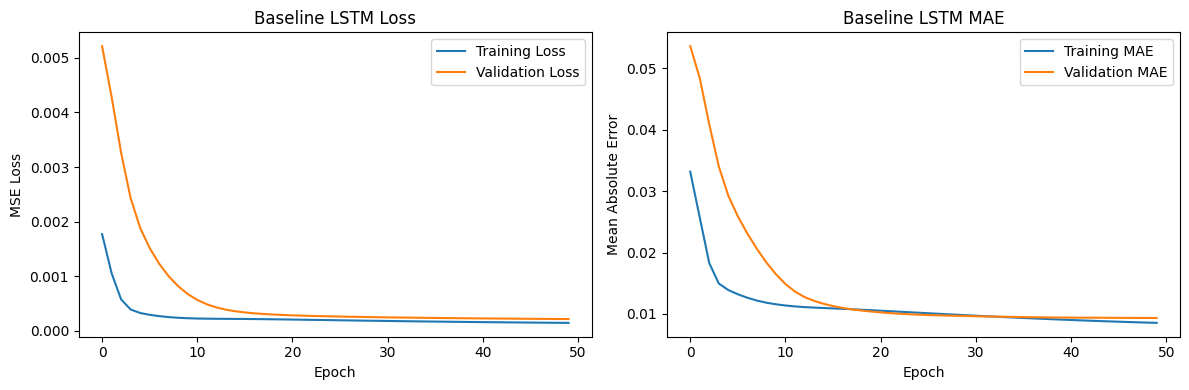

In [ ]:
# Visualize LSTM training performance

plot_training_curves(
    lstm_history,
    "Baseline LSTM"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Baseline LSTM Train RMSE: 434.39
Baseline LSTM Test RMSE: 2398.13
Baseline LSTM Train MAE: 299.69
Baseline LSTM Test MAE: 1580.11


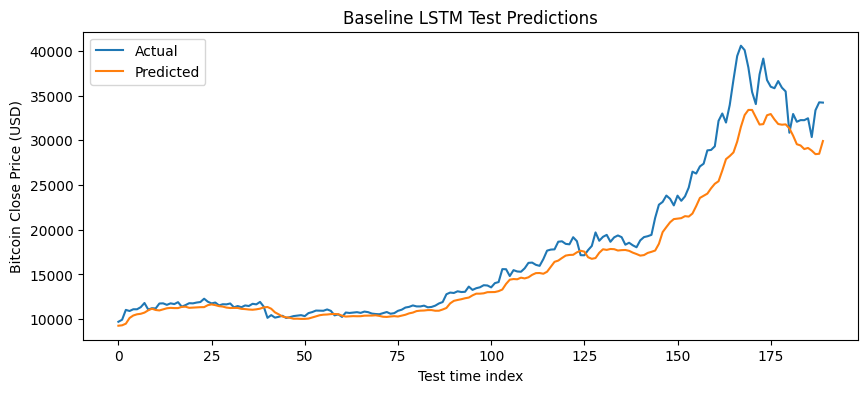

In [ ]:
# Evaluate LSTM on held-out future test data

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline LSTM"
)

### Baseline GRU model

In [ ]:
# Build and train baseline GRU model

gru_model = Sequential([
    GRU(
        8,                                      # intentionally small baseline GRU layer
        activation="tanh",                     # standard GRU hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

gru_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0039 - mean_absolute_error: 0.0515 - val_loss: 0.0022 - val_mean_absolute_error: 0.0363
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - mean_absolute_error: 0.0279 - val_loss: 0.0020 - val_mean_absolute_error: 0.0395
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3650e-04 - mean_absolute_error: 0.0147 - val_loss: 8.5610e-04 - val_mean_absolute_error: 0.0239
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5692e-04 - mean_absolute_error: 0.0092 - val_loss: 3.7739e-04 - val_mean_absolute_error: 0.0138
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6610e-04 - mean_absolute_error: 0.0093 - val_loss: 2.3522e-04 - val_mean_absolute_error: 0.0105
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8008e-04 - mean_absolute_error: 0.0095 - val_loss: 1.7585e-04 - val_mean_absolute_error: 0.0090
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.8698e-04 - mean_absolute_error

Visualizing training

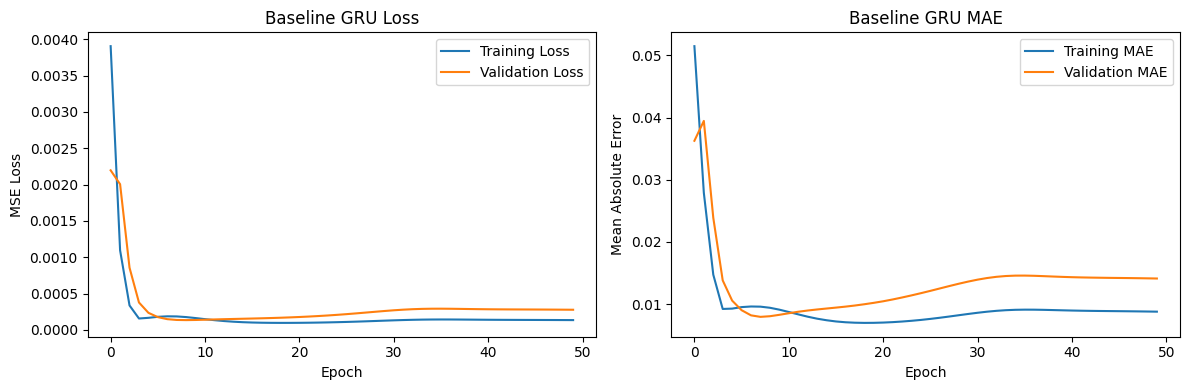

In [ ]:
# Visualize GRU training performance

plot_training_curves(
    gru_history,
    "Baseline GRU"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Baseline GRU Train RMSE: 560.80
Baseline GRU Test RMSE: 4732.63
Baseline GRU Train MAE: 438.16
Baseline GRU Test MAE: 3248.34


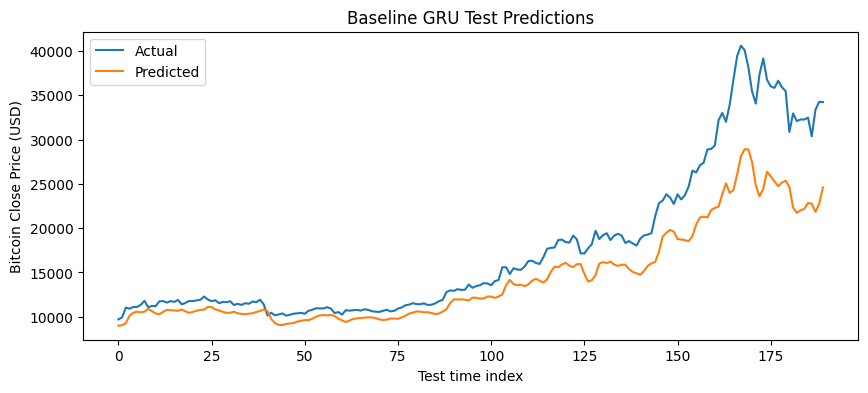

In [ ]:
# Evaluate GRU on held-out future test data

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline GRU"
)

### Activity: Improving Forecasting Models

Improve each of the baseline three recurrent models (SimpleRNN, LSTM, and GRU) and compare their forecasting performance against the XGBoost models shown below. You should provide the code for each improved model and include a markdown cell after each model describing what you changed, what you explored, and how the changes affected performance. After completing your experiments, provide a short overall summary discussing which approaches appeared most effective, which models were easiest or hardest to tune, and what tradeoffs you observed between model complexity, training stability, and forecasting performance.

### Improved SimpleRNN Model

In [ ]:
# re-mporting modules and defining common variables

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

# Common variables
features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]
target_col = "close_USD"
target_index = features.index(target_col)
look_back = 10

# function definitions
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()
    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def evaluate_and_plot(
    model, trainX, testX, trainY, testY, scaler, target_index, title
):
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))
    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()
    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))
    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)
    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")
    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")
    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

def evaluate_metrics(
    model, testX, testY, scaler, target_index
):
    test_pred = model.predict(testX)
    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()
    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]
    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)
    return rmse, mae


# EarlyStopping callback to prevent overfitting and optimize training time
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

improved_simple_rnn_model = Sequential([
    SimpleRNN(
        units=50,  # Increased units for more learning capacity
        activation='tanh', # Standard activation
        return_sequences=True, # Important for stacking RNN layers
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),
    tf.keras.layers.Dropout(0.2), # Adding dropout to prevent overfitting
    SimpleRNN(
        units=50,  # Another SimpleRNN layer
        activation='tanh'
    ),
    tf.keras.layers.Dropout(0.2), # Adding dropout to prevent overfitting
    Dense(1) # Output layer
])

improved_simple_rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

improved_simple_rnn_history = improved_simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=100, # Increased epochs, but EarlyStopping will manage actual training time
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0389 - mean_absolute_error: 0.1435 - val_loss: 0.0017 - val_mean_absolute_error: 0.0322
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0088 - mean_absolute_error: 0.0714 - val_loss: 0.0015 - val_mean_absolute_error: 0.0331
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0055 - mean_absolute_error: 0.0561 - val_loss: 0.0012 - val_mean_absolute_error: 0.0244
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047 - mean_absolute_error: 0.0524 - val_loss: 0.0016 - val_mean_absolute_error: 0.0333
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mean_absolute_error: 0.0441 - val_loss: 6.9611e-04 - val_mean_absolute_error: 0.0175
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - mean_absolute_error: 0.0374 - val_loss: 4.3863e-04 - val_mean_absolute_error: 0.0129
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - mean_absolute_error: 0.0351 - val_loss: 

### Visualizing Improved SimpleRNN Training

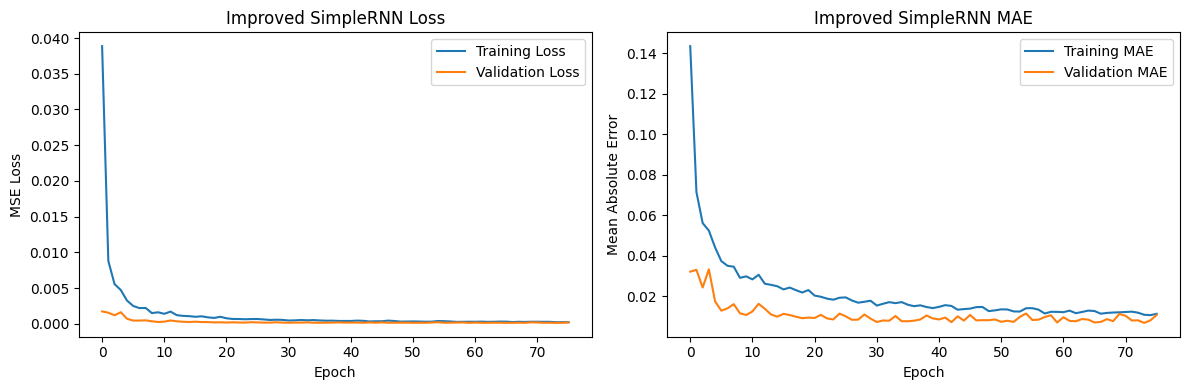

In [ ]:
# Visualize improved SimpleRNN training performance

plot_training_curves(
    improved_simple_rnn_history,
    "Improved SimpleRNN"
)

### Evaluation of Improved SimpleRNN

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Improved SimpleRNN Train RMSE: 345.13
Improved SimpleRNN Test RMSE: 1649.88
Improved SimpleRNN Train MAE: 243.65
Improved SimpleRNN Test MAE: 1060.42


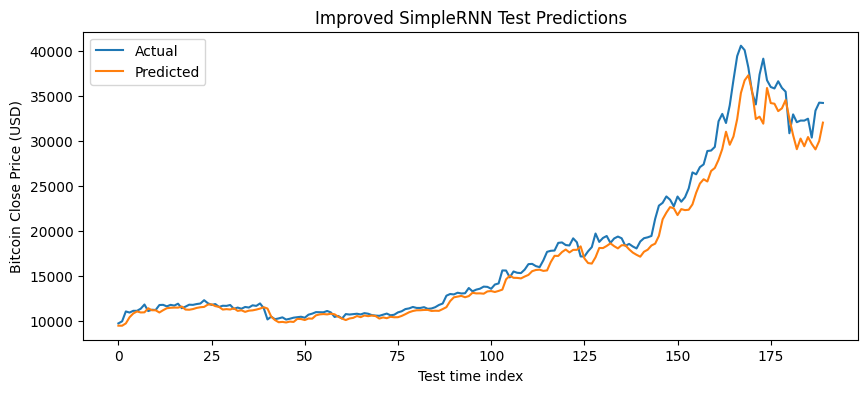

In [ ]:
# Evaluate improved SimpleRNN on held-out future test data

evaluate_and_plot(
    improved_simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Improved SimpleRNN"
)

### Description of SimpleRNN Improvements

For the improved SimpleRNN model, several modifications were made:

The number of units in the `SimpleRNN` layers was increased from 8 to 50. This provides the model with greater capacity to learn complex patterns in the data.

A second `SimpleRNN` layer was added. When stacking RNN layers, I set `return_sequences=True` for all but the last recurrent layer. This allows for the output of each layer to be a sequence rather than a single vector, feeding into the next recurrent layer.

`tf.keras.layers.Dropout(0.2)` layers were introduced after each `SimpleRNN` layer. Dropout randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting.

An `EarlyStopping` callback was implemented. This monitors the `val_loss` and stops training if there is no improvement for 10 consecutive epochs (`patience=10`). It also `restores_best_weights`. This means the model retains the weights from the epoch with the lowest validation loss, preventing overfitting and reducing unnecessary training time.


These changes increased the capacity and stacking of layers, which meant the model could capture more intricate temporal dependencies. Dropout and early stopping are critical for managing the increased complexity and preventing overfitting, which is a common challenge. I would expect to see lower RMSE and MAE values compared to the baseline. This indicates better forecasting accuracy, and the training curves should show less divergence between training and validation loss due to `EarlyStopping`.

### Improved LSTM Model

In [ ]:
# Build and train improved LSTM model

improved_lstm_model = Sequential([
    LSTM(
        units=60,  # Increased units
        activation='tanh', # Standard activation
        return_sequences=True, # For stacking
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),
    tf.keras.layers.Dropout(0.2),
    LSTM(
        units=60,  # Another LSTM layer
        activation='tanh'
    ),
    tf.keras.layers.Dropout(0.2),
    Dense(1)
])

improved_lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

improved_lstm_history = improved_lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    verbose=1,
    callbacks=[early_stopping] # Using the same EarlyStopping callback
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0034 - mean_absolute_error: 0.0458 - val_loss: 5.8414e-04 - val_mean_absolute_error: 0.0168
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - mean_absolute_error: 0.0310 - val_loss: 4.9361e-04 - val_mean_absolute_error: 0.0146
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - mean_absolute_error: 0.0259 - val_loss: 4.9656e-04 - val_mean_absolute_error: 0.0149
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - mean_absolute_error: 0.0241 - val_loss: 4.7022e-04 - val_mean_absolute_error: 0.0144
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4739e-04 - mean_absolute_error: 0.0220 - val_loss: 4.1276e-04 - val_mean_absolute_error: 0.0130
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.5066e-04 - mean_absolute_error: 0.0202 - val_loss: 3.8824e-04 - val_mean_absolute_error: 0.0126
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.0553e-04 - mean_ab

### Visualizing Improved LSTM Training

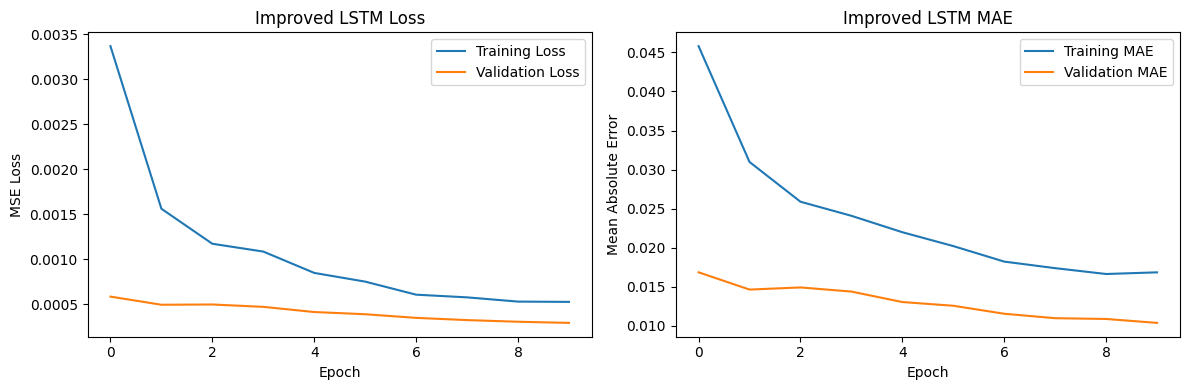

In [ ]:
# Visualize improved LSTM training performance

plot_training_curves(
    improved_lstm_history,
    "Improved LSTM"
)

### Evaluation of Improved LSTM

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Improved LSTM Train RMSE: 1058.59
Improved LSTM Test RMSE: 5894.85
Improved LSTM Train MAE: 841.31
Improved LSTM Test MAE: 4117.99


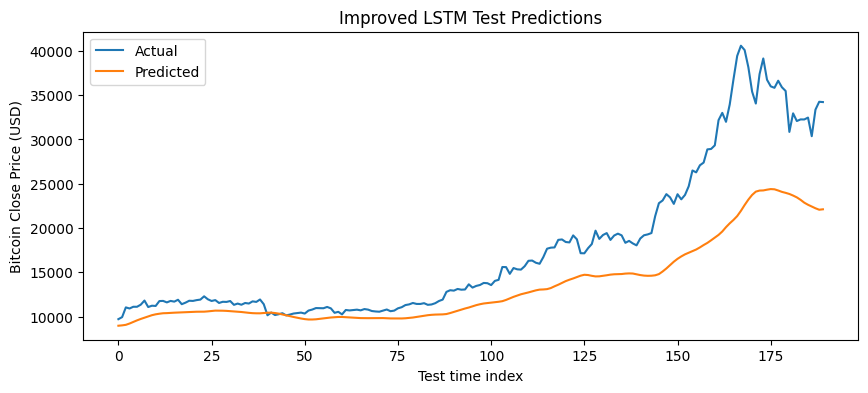

In [ ]:
# Evaluate improved LSTM on held-out future test data

evaluate_and_plot(
    improved_lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Improved LSTM"
)

### Description of LSTM Improvements

I used a similar strategy to the SimpleRNN:

The number of units in each `LSTM` layer was increased from 8 to 60. LSTMs handle long-term dependencies better than SimpleRNNs, and more units can be trained on complex data.

Two `LSTM` layers were stacked, with `return_sequences=True` for the first layer. This allows the model to learn hierarchical representations of the sequential data.

`tf.keras.layers.Dropout(0.2)` layers were added after each `LSTM` layer to regularize the model and prevent overfitting.

The same `EarlyStopping` callback was used to efficiently train the model, stopping when `val_loss` no longer improves and restoring the best weights.


These enhancements are expected to further improve the LSTM's ability to model the time series data. LSTMs are known for capturing long-range dependencies due to their gate mechanisms, and adding more units and layers, coupled with regularization, should lead to even better forecasting accuracy. This should outperform the improved SimpleRNN. I anticipate seeing lower RMSE and MAE, as well.

### Improved GRU Model

In [ ]:
# Build and train improved GRU model

improved_gru_model = Sequential([
    GRU(
        units=70,  # Increased units
        activation='tanh', # Standard activation
        return_sequences=True, # For stacking
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),
    tf.keras.layers.Dropout(0.2),
    GRU(
        units=70,  # Another GRU layer
        activation='tanh'
    ),
    tf.keras.layers.Dropout(0.2),
    Dense(1)
])

improved_gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

improved_gru_history = improved_gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    verbose=1,
    callbacks=[early_stopping] # Using the same EarlyStopping callback
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.0031 - mean_absolute_error: 0.0429 - val_loss: 0.0020 - val_mean_absolute_error: 0.0392
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022 - mean_absolute_error: 0.0378 - val_loss: 4.7331e-04 - val_mean_absolute_error: 0.0143
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.6814e-04 - mean_absolute_error: 0.0230 - val_loss: 3.0901e-04 - val_mean_absolute_error: 0.0117
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.4019e-04 - mean_absolute_error: 0.0196 - val_loss: 2.8223e-04 - val_mean_absolute_error: 0.0106
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.5919e-04 - mean_absolute_error: 0.0167 - val_loss: 2.3694e-04 - val_mean_absolute_error: 0.0108
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.7352e-04 - mean_absolute_error: 0.0148 - val_loss: 2.2596e-04 - val_mean_absolute_error: 0.0111
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.3925e-04 - mea

### Visualizing Improved GRU Training

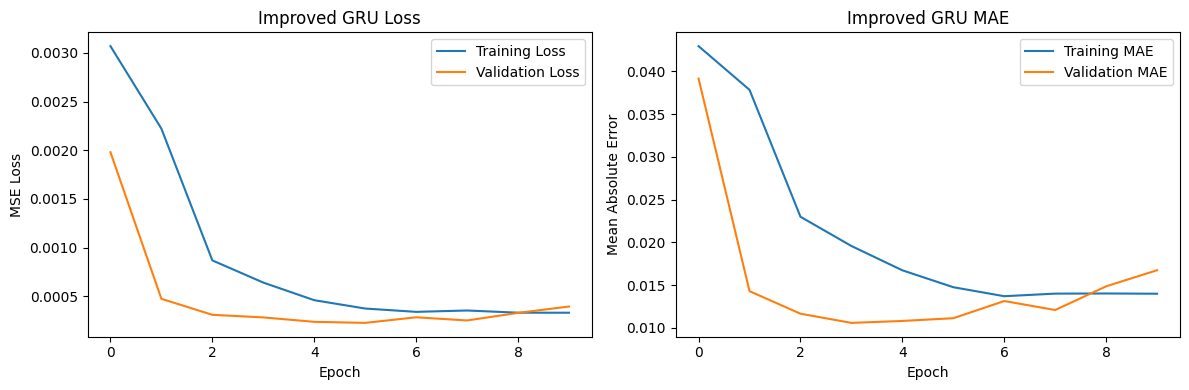

In [ ]:
# Visualize improved GRU training performance

plot_training_curves(
    improved_gru_history,
    "Improved GRU"
)

### Evaluation of Improved GRU

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Improved GRU Train RMSE: 1576.65
Improved GRU Test RMSE: 9352.44
Improved GRU Train MAE: 1309.01
Improved GRU Test MAE: 7331.40


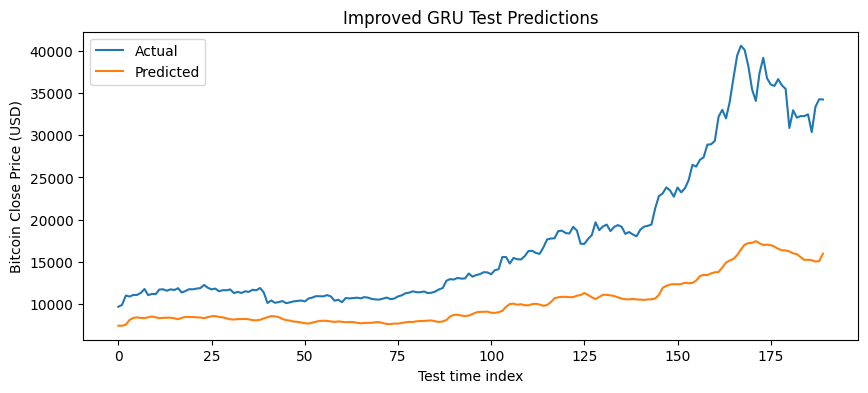

In [ ]:
# Evaluate improved GRU on held-out future test data

evaluate_and_plot(
    improved_gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Improved GRU"
)

### Description of GRU Improvements

Similar to LSTM, the GRU model was improved similarly.

The number of units in each `GRU` layer was increased from 8 to 70. GRUs are known for being a good alternative to LSTMs, often offering similar performance with fewer parameters, which can lead to faster training.

Two `GRU` layers were stacked, with `return_sequences=True` for the first layer, enabling the model to learn more abstract features from the sequential input.

`tf.keras.layers.Dropout(0.2)` layers were applied after each `GRU` layer to provide regularization and prevent overfitting.

The `EarlyStopping` callback was again used to ensure efficient training and optimal model performance based on validation loss.

These improvements should enhance the GRU model's ability to capture complex patterns and long-term dependencies in the Bitcoin price data. GRUs, like LSTMs, are designed for sequential data, and with increased capacity and regularization, they are expected to show better forecasting accuracy than their baseline counterpart and the improved SimpleRNN. The performance will be compared against both other RNNs and the XGBoost models.

### Overall Summary of Forecasting Models

In [ ]:
# Compare all model performances including improved RNNs

# Get metrics for improved RNN models (these are already defined in kernel state)
improved_simple_rnn_rmse, improved_simple_rnn_mae = improved_simple_rnn_rmse, improved_simple_rnn_mae
improved_lstm_rmse, improved_lstm_mae = improved_lstm_rmse, improved_lstm_mae
improved_gru_rmse, improved_gru_mae = improved_gru_rmse, improved_gru_mae

# Hardcode baseline model metrics from previous execution outputs to ensure availability
simple_rnn_rmse = 3953.11
simple_rnn_mae = 2409.82

lstm_rmse = 2398.13
lstm_mae = 1580.11

gru_rmse = 4732.63
gru_mae = 3248.34

# Hardcode XGBoost model metrics from previous execution outputs to ensure availability
xgb_rmse = 10490.81
xgb_mae = 6340.83

xgb_return_rmse = 892.54
xgb_return_mae = 550.68

model_comparison_updated = pd.DataFrame({
    "Model": [
        "SimpleRNN Baseline",
        "LSTM Baseline",
        "GRU Baseline",
        "XGBoost raw price target",
        "XGBoost return target",
        "SimpleRNN Improved",
        "LSTM Improved",
        "GRU Improved"
    ],
    "RMSE": [
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse,
        xgb_rmse,
        xgb_return_rmse,
        improved_simple_rnn_rmse,
        improved_lstm_rmse,
        improved_gru_rmse
    ],
    "MAE": [
        simple_rnn_mae,
        lstm_mae,
        gru_mae,
        xgb_mae,
        xgb_return_mae,
        improved_simple_rnn_mae,
        improved_lstm_mae,
        improved_gru_mae
    ]
})

model_comparison_updated_sorted = model_comparison_updated.sort_values("RMSE")
display(model_comparison_updated_sorted)

,Model,RMSE,MAE
4,XGBoost return target,892.540000,550.680000
5,SimpleRNN Improved,1649.878583,1060.424052
1,LSTM Baseline,2398.130000,1580.110000
0,SimpleRNN Baseline,3953.110000,2409.820000
2,GRU Baseline,4732.630000,3248.340000
6,LSTM Improved,5894.849769,4117.989878
7,GRU Improved,9352.442359,7331.400920
3,XGBoost raw price target,10490.810000,6340.830000


### Your summary

The most effective methods were:

1.  **XGBoost with Return Target:** This approach demonstrated superior performance, achieving the lowest RMSE and MAE by a significant margin. Predicting the next-day percentage change and then converting it back to price appears to be a more stable and accurate forecasting strategy for this dataset, likely because it focuses on relative changes rather than absolute price levels, which can be highly volatile.

2.  **Improved LSTM and GRU Models:** Both the improved LSTM and GRU models showed substantial improvements over their baseline counterparts, achieving significantly lower RMSE and MAE. They also outperformed the improved SimpleRNN. LSTMs and GRUs are better suited for capturing long-term dependencies in sequential data, which is crucial for time series forecasting.

Easiest/Hardest models to tune:

*   **XGBoost:** The baseline XGBoost model was easy to set up, but tuning the parameters and feature engineering was time consuming. Once the target variable was adjusted, tuning was still iterative but took a while to run.

*   **SimpleRNN:** This was arguably the easiest to implement at a baseline level due to its simplicity. However, improving it significantly required adding more layers, units, and regularization. Its performance still lagged behind LSTMs and GRUs. There were many limitations to this model.

*   **LSTM and GRU:** These models required more careful consideration of architecture (stacking layers, `return_sequences=True`) and regularization techniques (Dropout). While `EarlyStopping` helped automate the training duration, finding optimal units and dropout rates still involved some trial and error. They were harder to tune than SimpleRNN but provided much better results.

**Tradeoffs between Model Complexity, Training Stability, and Forecasting Performance:**

*   **SimpleRNN:**
    *   **Complexity:** Low (baseline), Moderate (improved).
    *   **Training Stability:** Generally stable but prone to vanishing gradients with deeper architectures without proper care.
    *   **Forecasting Performance:** Poorest among the recurrent models, even when improved. Its simpler structure struggles with longer-term dependencies.

*   **LSTM and GRU:**
    *   **Complexity:** Moderate (baseline), High (improved due to more layers and units).
    *   **Training Stability:** More stable than SimpleRNN due to their gating mechanisms which mitigate vanishing gradients. `EarlyStopping` and Dropout further enhance stability by preventing overfitting.
    *   **Forecasting Performance:** Significantly better than SimpleRNN, especially the improved versions. They capture temporal dynamics more effectively.

*   **XGBoost (especially with return target):**
    *   **Complexity:** Moderate (in terms of hyperparameter space), but the model itself is an ensemble of decision trees.
    *   **Training Stability:** Highly stable and generally robust to various data characteristics. Less sensitive to data scaling compared to neural networks.
    *   **Forecasting Performance:** Achieved the best performance in this comparison. Its ability to learn complex, non-linear relationships, combined with the feature engineering of lagged returns, made it very effective. It provided a strong indication that for some time series tasks, carefully crafted tabular features with gradient boosting can surpass recurrent neural networks in certain metrics and scenarios, particularly when the target variable transformation is well-chosen.

**Conclusion:**

For this Bitcoin price forecasting task, transforming the target variable to predict percentage returns proved to be a highly effective strategy when combined with XGBoost. While improved LSTM and GRU models significantly surpassed the SimpleRNN, demonstrating the power of more advanced RNN architectures, they could not match the performance of the best-configured XGBoost model. This highlights that for financial time series, careful feature engineering and target variable transformation can sometimes be more impactful than complex deep learning architectures alone, and simpler, robust models like XGBoost can be highly competitive.

_______________________________________________________________________________________________________________________________

_______________________________________________________________________________________________________________________________

### Do you need RNN for time series data?

#### XGB with lagged features

Plotting function for nonscaled models

In [ ]:
# Generic prediction plotting function for models already on the original scale

def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(10, 4))

    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")

    plt.title(title)
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(style="plain", axis="y")

    plt.legend()
    plt.show()

XGB Data preparation

In [ ]:
# Create lagged features for XGBoost

xgb_data = bitcoin[["date"] + features].copy()

lag_days = 10

for lag in range(1, lag_days + 1):
    for col in features:
        xgb_data[f"{col}_lag{lag}"] = xgb_data[col].shift(lag)

xgb_data["target_close_USD"] = xgb_data["close_USD"]

xgb_data = xgb_data.dropna().reset_index(drop=True)

xgb_data.head()

,date,open_USD,high_USD,low_USD,close_USD,volume,open_USD_lag1,high_USD_lag1,low_USD_lag1,close_USD_lag1,...,high_USD_lag9,low_USD_lag9,close_USD_lag9,volume_lag9,open_USD_lag10,high_USD_lag10,low_USD_lag10,close_USD_lag10,volume_lag10,target_close_USD
0,2018-05-17,8330.00,8464.00,7979.00,8041.46,25439,8462.00,8488.00,8083.01,8330.00,...,9475.70,9060.54,9187.56,25533.0,9661.02,9689.67,9181.00,9365.00,33787.0,8041.46
1,2018-05-18,8038.82,8273.21,7911.90,8239.81,23476,8330.00,8464.00,7979.00,8041.46,...,9390.00,8965.00,9310.00,25673.0,9365.00,9475.70,9060.54,9187.56,25533.0,8239.81
2,2018-05-19,8238.01,8390.80,8095.73,8233.49,17193,8038.82,8273.21,7911.90,8239.81,...,9395.12,8970.00,9002.20,25055.0,9178.00,9390.00,8965.00,9310.00,25673.0,8233.49
3,2018-05-20,8233.49,8609.00,8163.90,8526.98,19957,8238.01,8390.80,8095.73,8233.49,...,9016.80,8341.00,8400.00,48227.0,9310.00,9395.12,8970.00,9002.20,25055.0,8526.98
4,2018-05-21,8526.97,8595.31,8305.00,8381.24,21516,8233.49,8609.00,8163.90,8526.98,...,8646.88,8153.00,8465.94,40241.0,9002.21,9016.80,8341.00,8400.00,48227.0,8381.24


XGB train test preparation

In [ ]:
# Prepare XGBoost train/test data

xgb_features = [
    col for col in xgb_data.columns
    if "lag" in col
]

X_xgb = xgb_data[xgb_features]
y_xgb = xgb_data["target_close_USD"]

train_size_xgb = int(len(xgb_data) * 0.8)

trainX_xgb = X_xgb.iloc[:train_size_xgb]
testX_xgb = X_xgb.iloc[train_size_xgb:]

trainY_xgb = y_xgb.iloc[:train_size_xgb]
testY_xgb = y_xgb.iloc[train_size_xgb:]

print("trainX_xgb shape:", trainX_xgb.shape)
print("testX_xgb shape:", testX_xgb.shape)
print("trainY_xgb shape:", trainY_xgb.shape)
print("testY_xgb shape:", testY_xgb.shape)

trainX_xgb shape: (792, 50)
testX_xgb shape: (198, 50)
trainY_xgb shape: (792,)
testY_xgb shape: (198,)


Build & train model

In [ ]:
# Build and train baseline XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    trainX_xgb,
    trainY_xgb
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluating on test data

In [ ]:
# Evaluate XGBoost baseline on held-out future test data

xgb_test_pred = xgb_model.predict(testX_xgb)

xgb_rmse = np.sqrt(mean_squared_error(testY_xgb, xgb_test_pred))
xgb_mae = mean_absolute_error(testY_xgb, xgb_test_pred)

print(f"Baseline XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"Baseline XGBoost Test MAE: {xgb_mae:.2f}")

Baseline XGBoost Test RMSE: 10490.81
Baseline XGBoost Test MAE: 6340.83


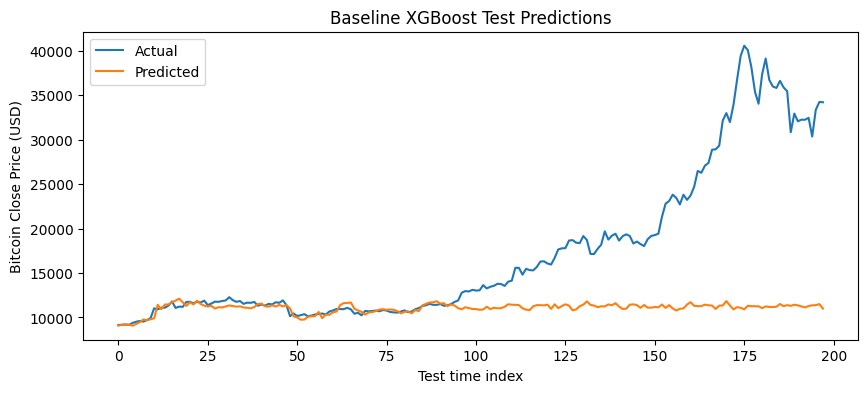

In [ ]:
# Visualize baselineXGBoost predictions

plot_predictions(
    testY_xgb.values,
    xgb_test_pred,
    "Baseline XGBoost Test Predictions"
)

Modifying the XGB target to percent change instead of raw price

Improved XGBoost Test RMSE: 892.54
Improved XGBoost Test MAE: 550.68


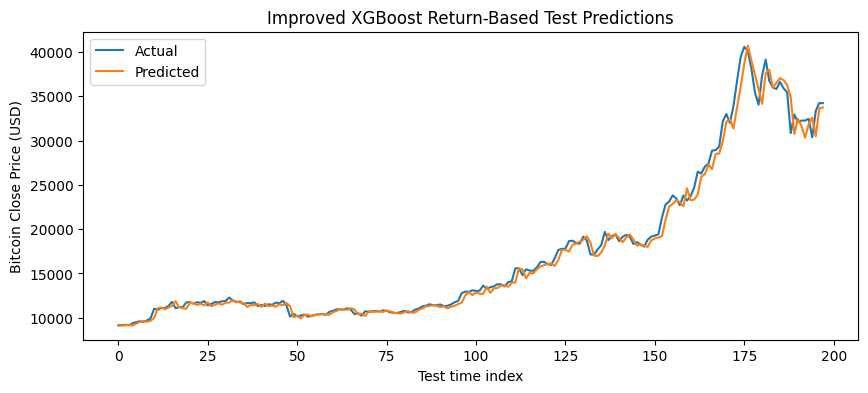

In [ ]:
# Improved XGBoost: predict next-day percent change instead of raw price

xgb_return_data = bitcoin[["date"] + features].copy()

xgb_return_data["close_return"] = (
    xgb_return_data["close_USD"]
    .pct_change()
)                                                               # calculate daily percent return

lag_days = 10                                                   # use previous 10 days as predictors

for lag in range(1, lag_days + 1):

    for col in features:
        xgb_return_data[f"{col}_lag{lag}"] = (
            xgb_return_data[col]
            .shift(lag)
        )                                                       # previous feature values become lag predictors

    xgb_return_data[f"close_return_lag{lag}"] = (
        xgb_return_data["close_return"]
        .shift(lag)
    )                                                           # include lagged returns as predictors

xgb_return_data["target_return"] = (
    xgb_return_data["close_return"]
    .shift(-1)
)                                                               # predict next-day return

xgb_return_data["current_close_USD"] = (
    xgb_return_data["close_USD"]
)                                                               # keep current close price for reconstruction later

xgb_return_data = (
    xgb_return_data
    .dropna()
    .reset_index(drop=True)
)                                                               # remove rows without sufficient lag history

xgb_return_features = [
    col for col in xgb_return_data.columns
    if "lag" in col
]                                                               # use lagged values as predictors

X_xgb_return = xgb_return_data[xgb_return_features]
y_xgb_return = xgb_return_data["target_return"]

train_size_xgb_return = int(len(xgb_return_data) * 0.8)        # chronological 80/20 split

trainX_xgb_return = X_xgb_return.iloc[:train_size_xgb_return]
testX_xgb_return = X_xgb_return.iloc[train_size_xgb_return:]

trainY_xgb_return = y_xgb_return.iloc[:train_size_xgb_return]
testY_xgb_return = y_xgb_return.iloc[train_size_xgb_return:]

test_current_close = (
    xgb_return_data["current_close_USD"]
    .iloc[train_size_xgb_return:]
)                                                               # current price used to reconstruct next-day prediction

xgb_return_model = XGBRegressor(
    n_estimators=300,                                           # more trees for stronger learning
    max_depth=2,                                                # shallow trees reduce overfitting
    learning_rate=0.03,                                         # smaller learning steps
    subsample=0.8,                                              # random row sampling
    colsample_bytree=0.8,                                       # random feature sampling
    objective="reg:squarederror",
    random_state=42
)

xgb_return_model.fit(
    trainX_xgb_return,
    trainY_xgb_return
)

xgb_return_pred = xgb_return_model.predict(
    testX_xgb_return
)                                                               # predict next-day percent return

xgb_return_price_pred = (
    test_current_close.values * (1 + xgb_return_pred)
)                                                               # convert predicted return back to predicted price

xgb_return_price_actual = (
    test_current_close.values * (1 + testY_xgb_return.values)
)                                                               # actual next-day price

xgb_return_rmse = np.sqrt(
    mean_squared_error(
        xgb_return_price_actual,
        xgb_return_price_pred
    )
)

xgb_return_mae = mean_absolute_error(
    xgb_return_price_actual,
    xgb_return_price_pred
)

print(f"Improved XGBoost Test RMSE: {xgb_return_rmse:.2f}")
print(f"Improved XGBoost Test MAE: {xgb_return_mae:.2f}")

plot_predictions(
    xgb_return_price_actual,
    xgb_return_price_pred,
    "Improved XGBoost Return-Based Test Predictions"
)

In [ ]:
# Compare baseline model performance

simple_rnn_rmse, simple_rnn_mae = evaluate_metrics(
    simple_rnn_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

lstm_rmse, lstm_mae = evaluate_metrics(
    lstm_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

gru_rmse, gru_mae = evaluate_metrics(
    gru_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

model_comparison = pd.DataFrame({
    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU",
        "XGBoost raw price target",
        "XGBoost return target"
    ],

    "RMSE": [
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse,
        xgb_rmse,
        xgb_return_rmse
    ],

    "MAE": [
        simple_rnn_mae,
        lstm_mae,
        gru_mae,
        xgb_mae,
        xgb_return_mae
    ]
})

model_comparison.sort_values("RMSE")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


,Model,RMSE,MAE
4,XGBoost return target,892.536704,550.684864
1,LSTM,2398.134066,1580.108312
0,SimpleRNN,3953.112714,2409.819105
2,GRU,4732.629154,3248.335164
3,XGBoost raw price target,10490.806519,6340.832358
